In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load your Task 1 enriched dataset
main_df = pd.read_excel("../data/processed/ethiopia_fi_unified_data_enriched.xlsx", sheet_name="ethiopia_fi_unified_data")
impact_df = pd.read_excel("../data/processed/ethiopia_fi_unified_data_enriched.xlsx", sheet_name="Impact_sheet")
main_df['observation_date'] = pd.to_datetime(main_df['observation_date'])


 **Dataset Overview**

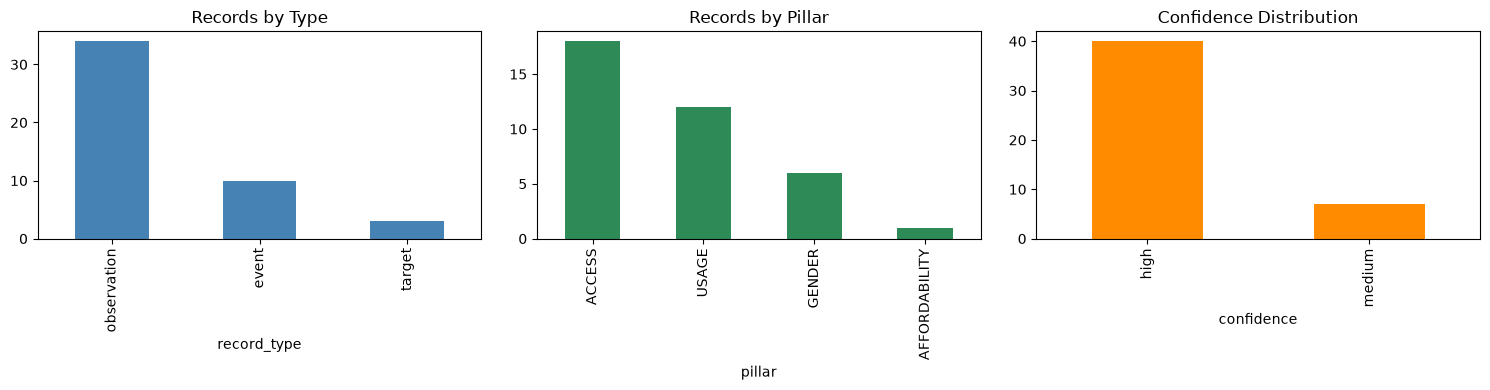

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

main_df['record_type'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Records by Type')

main_df[main_df['record_type'].isin(['observation','target'])]['pillar'].value_counts().plot(
    kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Records by Pillar')

main_df['confidence'].value_counts().plot(kind='bar', ax=axes[2], color='darkorange')
axes[2].set_title('Confidence Distribution')
plt.savefig('../reports/dataset_overview.png', dpi=120)


plt.tight_layout()
plt.show()

**Temporal coverage heatmap — which indicators have data in which years**

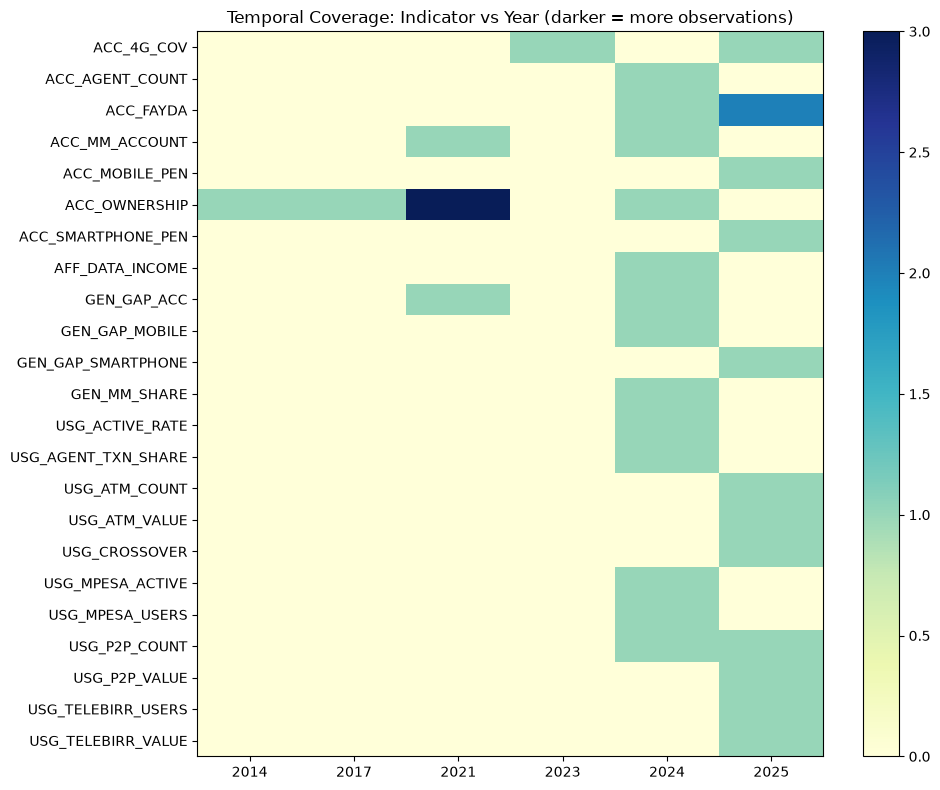

Sparse indicators (only 1 year of data):
['ACC_AGENT_COUNT', 'ACC_MOBILE_PEN', 'ACC_SMARTPHONE_PEN', 'AFF_DATA_INCOME', 'GEN_GAP_MOBILE', 'GEN_GAP_SMARTPHONE', 'GEN_MM_SHARE', 'USG_ACTIVE_RATE', 'USG_AGENT_TXN_SHARE', 'USG_ATM_COUNT', 'USG_ATM_VALUE', 'USG_CROSSOVER', 'USG_MPESA_ACTIVE', 'USG_MPESA_USERS', 'USG_P2P_VALUE', 'USG_TELEBIRR_USERS', 'USG_TELEBIRR_VALUE']


<Figure size 640x480 with 0 Axes>

In [17]:
obs = main_df[main_df['record_type']=='observation'].copy()
obs['year'] = obs['observation_date'].dt.year
coverage = obs.pivot_table(index='indicator_code', columns='year', values='value_numeric', aggfunc='count').fillna(0)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(coverage, cmap='YlGnBu', aspect='auto')
ax.set_xticks(range(len(coverage.columns))); ax.set_xticklabels(coverage.columns)
ax.set_yticks(range(len(coverage.index))); ax.set_yticklabels(coverage.index)
ax.set_title('Temporal Coverage: Indicator vs Year (darker = more observations)')
plt.colorbar(im)
plt.tight_layout()
plt.show()

print("Sparse indicators (only 1 year of data):")
plt.savefig('../reports/section1_coverage_heatmap.png', dpi=120)

print(coverage[(coverage > 0).sum(axis=1) == 1].index.tolist())

**SECTION 2: Access Analysis — Account Ownership trajectory**

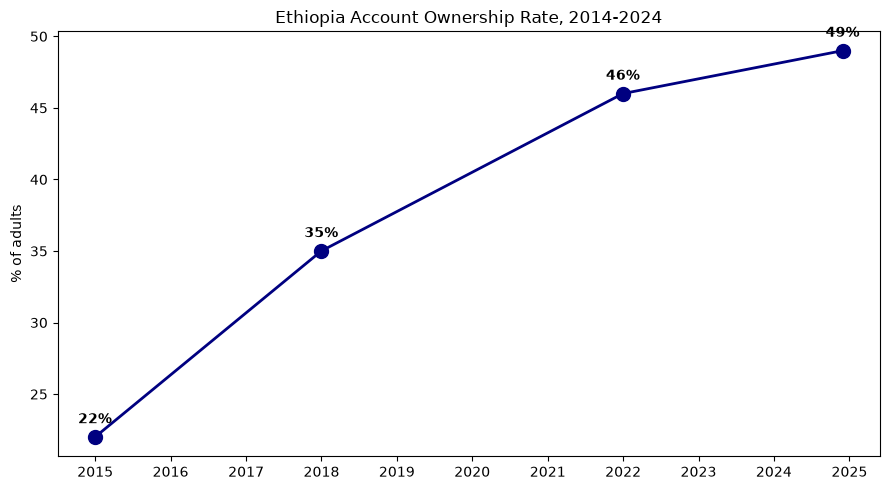

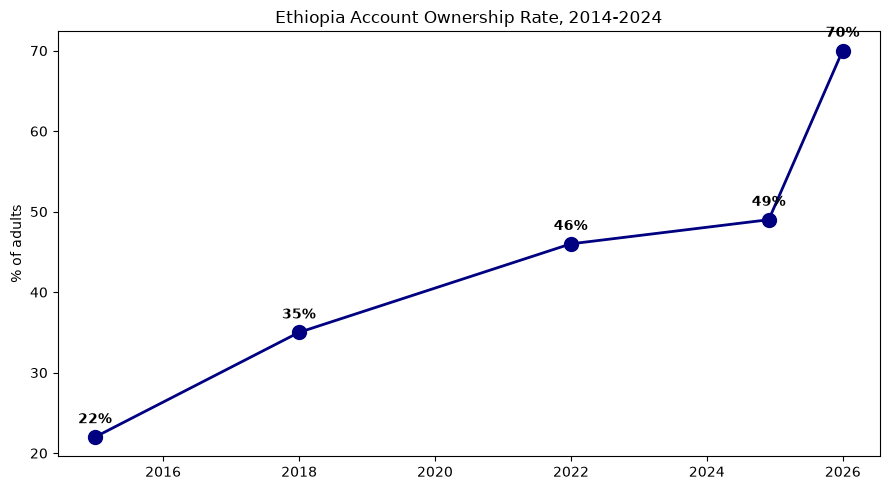

In [21]:
acc = main_df[(main_df['indicator_code']=='ACC_OWNERSHIP') &
              (main_df['gender']=='all') &
              (main_df['record_type']=='observation')].sort_values('observation_date')
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(acc['observation_date'], acc['value_numeric'], marker='o', markersize=10, linewidth=2, color='navy')
for _, row in acc.iterrows():
    ax.annotate(f"{row['value_numeric']:.0f}%", (row['observation_date'], row['value_numeric']),
                textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')
ax.set_title("Ethiopia Account Ownership Rate, 2014-2024")
ax.set_ylabel("% of adults")
plt.tight_layout()
acc = main_df[(main_df['indicator_code']=='ACC_OWNERSHIP') & (main_df['gender']=='all')].sort_values('observation_date')

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(acc['observation_date'], acc['value_numeric'], marker='o', markersize=10, linewidth=2, color='navy')
for _, row in acc.iterrows():
    ax.annotate(f"{row['value_numeric']:.0f}%", (row['observation_date'], row['value_numeric']),
                textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')
ax.set_title("Ethiopia Account Ownership Rate, 2014-2024")
ax.set_ylabel("% of adults")
plt.tight_layout()
plt.savefig('../reports/section2_acc_ownership_trajectory.png', dpi=120)
plt.show()
plt.show()

**Growth rates — annualized, since gaps between survey years differ (3yr, 4yr, 3yr)**

In [10]:
acc_growth = acc[['fiscal_year','value_numeric']].reset_index(drop=True)
acc_growth['change_pp'] = acc_growth['value_numeric'].diff()
acc_growth['years_elapsed'] = acc_growth['fiscal_year'].diff()
acc_growth['annualized_pp_per_year'] = acc_growth['change_pp'] / acc_growth['years_elapsed']
print("\nAccount Ownership growth rates:")
print(acc_growth)


Account Ownership growth rates:
  fiscal_year  value_numeric  change_pp years_elapsed annualized_pp_per_year
0        2014           22.0        NaN           NaN                    NaN
1        2017           35.0       13.0             3               4.333333
2        2021           46.0       11.0             4                   2.75
3        2024           49.0        3.0             3                    1.0
4        2025           70.0       21.0             1                   21.0


# Gender gap


In [11]:
gender_2021 = main_df[(main_df['indicator_code']=='ACC_OWNERSHIP') & (main_df['fiscal_year']==2021)]
print("\n2021 Account Ownership by gender:")
print(gender_2021[['gender','value_numeric']])
print("\nGender gap trend (GEN_GAP_ACC): 20pp (2021) -> 18pp (2024) — narrowing slowly, not closing")



2021 Account Ownership by gender:
   gender  value_numeric
2     all           46.0
3    male           56.0
4  female           36.0

Gender gap trend (GEN_GAP_ACC): 20pp (2021) -> 18pp (2024) — narrowing slowly, not closing


# SECTION 3: Usage Analysis — registered vs. active gap
# ═══════════════════════════════════════════════════════════════

In [12]:
mm_related = main_df[main_df['indicator_code'].isin(
    ['ACC_MM_ACCOUNT','USG_TELEBIRR_USERS','USG_MPESA_USERS','USG_MPESA_ACTIVE','USG_ACTIVE_RATE'])]
print("\nMobile money: registered vs. survey-measured ownership:")
print(mm_related[['observation_date','indicator','value_numeric','unit']])


Mobile money: registered vs. survey-measured ownership:
   observation_date                   indicator  value_numeric   unit
6        2021-12-31   Mobile Money Account Rate           4.70      %
7        2024-11-29   Mobile Money Account Rate           9.45      %
20       2025-06-30   Telebirr Registered Users    54840000.00  users
22       2024-12-31     M-Pesa Registered Users    10800000.00  users
23       2024-12-31  M-Pesa 90-Day Active Users     7100000.00  users
24       2024-12-31  Mobile Money Activity Rate          66.00      %


KEY INSIGHT: Telebirr alone = 54.84M registered users, but survey-measured
Mobile Money Account Rate is only 9.45% of adults (2024). M-Pesa shows the
gap directly: 10.8M registered, only 7.1M are 90-day active (66% activity rate).


# Infrastructure and Enablers


In [13]:
infra = main_df[main_df['indicator_code'].isin(['ACC_4G_COV','ACC_FAYDA'])].sort_values('observation_date')
print("\nInfrastructure trend:")
print(infra[['observation_date','indicator','value_numeric','unit']])


Infrastructure trend:
   observation_date                    indicator  value_numeric    unit
8        2023-06-30       4G Population Coverage           37.5       %
11       2024-08-15  Fayda Digital ID Enrollment      8000000.0  people
12       2025-02-28  Fayda Digital ID Enrollment     12000000.0  people
13       2025-05-15  Fayda Digital ID Enrollment     15000000.0  people
9        2025-06-30       4G Population Coverage           70.8       %
31       2028-12-31  Fayda Digital ID Enrollment     90000000.0  people


# SECTION 5: Event Timeline overlay
# ═══════════════════════════════════════════════════════════════

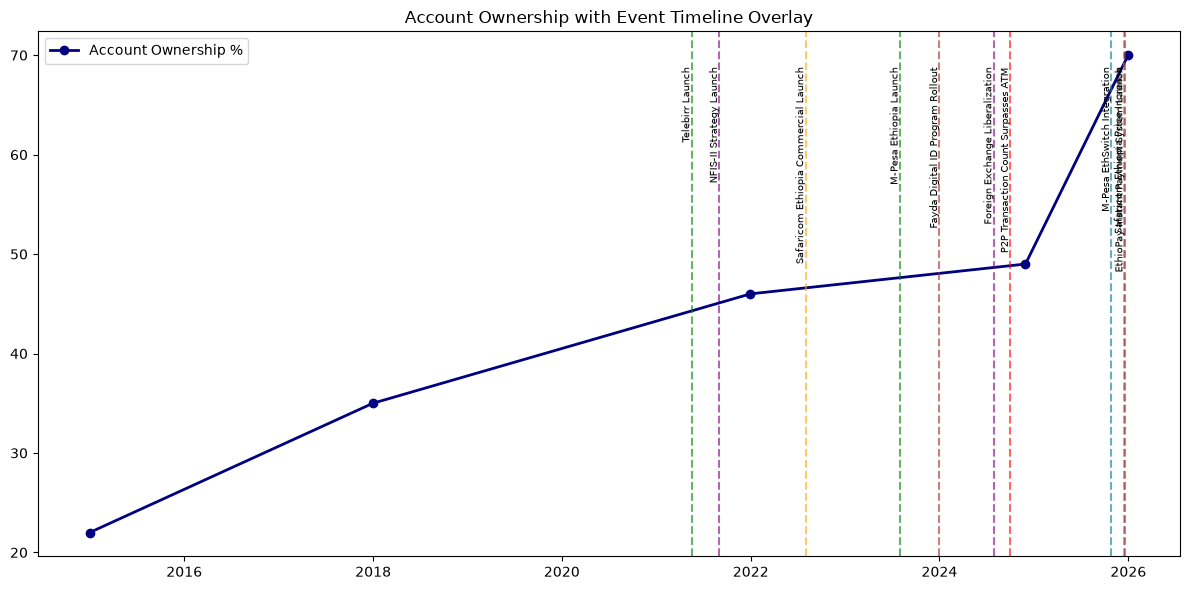

In [15]:
events = main_df[main_df['record_type']=='event'].sort_values('observation_date')

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(acc['observation_date'], acc['value_numeric'], marker='o', linewidth=2, color='navy', label='Account Ownership %')

colors = {'product_launch':'green','policy':'purple','market_entry':'orange',
          'infrastructure':'brown','milestone':'red','partnership':'teal','pricing':'gray'}
for _, e in events.iterrows():
    ax.axvline(e['observation_date'], color=colors.get(e['category'],'black'), linestyle='--', alpha=0.6)
    ax.text(e['observation_date'], ax.get_ylim()[1]*0.95, e['indicator'],
            rotation=90, fontsize=7, va='top', ha='right')

ax.set_title("Account Ownership with Event Timeline Overlay")
ax.legend()
plt.tight_layout()
plt.savefig('../reports/section5_event_timeline.png', dpi=120)
plt.show()


# Key Insights — Task 2 (Exploratory Data Analysis)

## 1. Account Ownership growth is genuinely decelerating, not just slowing due to uneven survey gaps
Annualized growth was +4.3pp/year (2014-17), +2.75pp/year (2017-21), and only +1.0pp/year
(2021-24). Adjusting for the fact that survey intervals differ (3, 4, 3 years) doesn't
explain away the slowdown — it confirms it. Something structural changed after 2021, not
just a shorter measurement window.

## 2. The "registered vs. active" gap is likely the single biggest explanation for the 2021-2024 stagnation
Telebirr alone reports 54.84 million registered users by mid-2025, yet Findex's own Mobile
Money Account Rate — which asks whether someone *personally used* a service in the past 12
months — was only 9.45% of adults in 2024. M-Pesa's own numbers make the mechanism visible
directly: 10.8M registered, but only 7.1M (66%) are 90-day active. Mass sign-ups don't
automatically become Findex-countable "account owners" — a large share of registrations
appear to be dormant, duplicated across Telebirr/M-Pesa/bank accounts, or below the usage
threshold Findex requires.

## 3. Infrastructure expansion has outpaced Access growth, suggesting infrastructure isn't the current bottleneck
4G population coverage nearly doubled (37.5% → 70.8%) between 2023 and 2025 — a massive
supply-side investment — while Account Ownership moved only 3pp in a comparable window. If
coverage were the binding constraint, we'd expect Access to track it more closely. This
points toward demand-side barriers instead (affordability, trust, agent quality, gender
norms) as more likely explanations.

## 4. The gender gap is narrowing, but very slowly, and unevenly across indicators
Account Ownership's gender gap went from 20pp (2021) to 18pp (2024) — real but marginal
progress. Meanwhile the *smartphone-specific* gender gap is far starker (18% male vs. 6%
female ownership, a much wider proportional gap than basic phone ownership's 24pp),
suggesting the gender gap is not closing evenly — it's shifting to a new frontier (device
tier) as basic access improves.

## 5. Agent network scale doesn't equal agent network utilization, and this likely constrains Usage growth
Telebirr has ~216,000 registered agents, but agent-facilitated transactions are only 17% of
total mobile money transaction volume, with each agent averaging fewer than 1 transaction
per day. A large registered network that's mostly idle can't drive the "usage" side of
inclusion the way an active, trusted agent network could — this matches Kenya's more
agent-driven model, which Ethiopia hasn't replicated.

## Data gaps limiting this analysis
Most indicators have only 1-2 data points total (visible in the coverage heatmap), meaning
we can describe direction but can't statistically validate most correlations — this is a
real constraint for Task 3's causal/impact modeling, not just a Task 2 footnote.

## Hypotheses for the impact modeling phase
- The registered-vs-active gap, not raw sign-ups, should be the feature that predicts
  Findex-measured Access.
- Infrastructure variables (4G, Fayda) may function as leading indicators with a lag rather
  than same-year correlates.
- Gender-disaggregated features may need separate models rather than one aggregate model,
  since gaps are evolving unevenly across device tiers.

# Data Quality Assessment — Task 2

## Confidence Levels
Of the 47 records in the enriched dataset, 40 are rated `high` confidence and 7 are
`medium`. The `medium` records are entirely the four Task 1 enrichment additions
(smartphone penetration, smartphone gender gap, agent count, agent transaction share),
which come from research/news outlets citing primary sources (GSMA, Ethio Telecom) rather
than the primary reports themselves. No record in the dataset is rated `low` confidence.

## Source Type Distribution
Sources lean heavily toward `operator` (15) and `survey` (10) records — i.e., real
company reporting and Findex survey data, not estimates or guesses. `regulator` (7) and
`policy` (3) add official-source grounding. Only 4 `research` and 2 `news` records exist,
concentrated in the enrichment additions.

## Temporal Coverage Gaps
The coverage heatmap shows a clear pattern: **`ACC_OWNERSHIP` is the only indicator with
genuine multi-year, repeated-measurement coverage** (2014, 2017, 2021, 2024 — 4 distinct
years). Every other indicator in the dataset has data in only 1-2 years:

- Most Usage indicators (`USG_TELEBIRR_USERS`, `USG_MPESA_USERS`, `USG_P2P_VALUE`,
  `USG_ATM_COUNT`, etc.) are single-year snapshots, typically from 2024-2025 only.
- Infrastructure indicators (`ACC_4G_COV`, `ACC_FAYDA`) have 2 points each, both recent
  (2023-2025), giving a before/after comparison but no long-run trend.
- Gender-disaggregated indicators (`GEN_GAP_ACC`, `GEN_GAP_MOBILE`, `GEN_MM_SHARE`) are
  similarly thin, with 1-2 data points each.

**Implication:** any trend line other than `ACC_OWNERSHIP` is really a two-point
comparison, not a fitted trend. This is an honest limitation to carry into Task 3 —
forecasting Usage indicators will require either external data with more history, or
modeling approaches that don't assume a smooth multi-point trend exists where it doesn't.

## Structural Limitation: Correlation Analysis
Because most indicators have only 1-2 observations, a standard correlation matrix across
indicators is not statistically meaningful — correlation requires enough paired
observations to detect a real relationship, and most indicator pairs here don't overlap
in more than one shared year. Where this document points to relationships (e.g.,
infrastructure growth vs. Account Ownership growth), these are **directional
before/after comparisons**, not computed correlation coefficients. This distinction is
made explicit rather than implied, to avoid overstating statistical rigor the data
doesn't support.

## Known Gaps Not Addressed in This Pass
- Urban vs. rural disaggregation for Account Ownership is not present in the dataset at
  all (only gender disaggregation exists for 2021).
- No repeated year-over-year data exists for mobile money account penetration
  specifically (`ACC_MM_ACCOUNT` has only 2 points: 2021 and 2024).
- Several existing impact_links (from Task 1) rely on cross-country literature estimates
  (Kenya, India) rather than empirical Ethiopian measurement, since Ethiopia's own
  post-launch history is still short — this affects how much weight those relationships
  should carry in Task 3's modeling.